# IPW in Practice

In [91]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

from graphviz import Digraph
from IPython.display import display


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

## Recap: The Core Idea of IPW

Our goal is to estimate $ATE = \mathbb{E}[Y_1 - Y_0]$, the average difference in outcomes between receiving and not receiving a treatment across the entire population. In the medication example, this means asking: how much does the average number of hospitalization days differ between a world where everyone takes the drug and one where no one does?

Let's revisit the example below.

In [93]:
drug_example = pd.DataFrame(dict(
    sex= ["M","M","M","M","M","M", "W","W","W","W"],
    drug=[1,1,1,1,1,0,  1,0,1,0],
    days=[5,5,5,5,5,8,  2,4,2,4]
))

In reality, we cannot observe both $Y_0$ and $Y_1$ for the same person at the same time. For the sake of explanation, however, let's pretend we can see both worlds simultaneously.

Under this assumption, the individual treatment effects by sex are:

- Male: $Y_1 = 5, Y_0 = 8 \Rightarrow Y_1 - Y_0 = -3$
- Female: $Y_1 = 2, Y_0 = 4 \Rightarrow Y_1 - Y_0 = -2$

Since there are 6 males (each with a −3 day effect) and 4 females (each with a −2 day effect), the true ATE is:

$$
ATE = \frac{-3 \times 6 + (-2) \times 4}{10} = -2.6
$$

In other words, taking the drug should reduce hospitalization days by 2.6 on average. This is the true effect we want to recover.

What happens if we simply compare group means (naive estimate)?

The treated group average is $(5 \times 5 + 2 \times 2)/7 = 29/7$, and the untreated group average is $(1 \times 8 + 2 \times 4)/3 = 16/3$. Let's compute the difference.

In [94]:
print("Naive:", drug_example.query("drug==1")["days"].mean() - drug_example.query("drug==0")["days"].mean())

Naive: -1.1904761904761898


The result is $-1.19$, far from the true $ATE = -2.6$. This distortion doesn't come from the drug's effect — it comes from the difference in group composition, specifically the different sex distributions between treated and untreated groups. When a variable affects both treatment assignment and the outcome like this, we call it a **confounder**, and the resulting bias is called **confounding**.

IPW (Inverse Probability Weighting) is one method designed to remove this confounding.

In [95]:
ps = drug_example.groupby("sex")["drug"].mean()
drug_example["ps"] = drug_example["sex"].map(ps)

drug_example["w"] = (
    drug_example["drug"]/drug_example["ps"] +
    (1-drug_example["drug"])/(1-drug_example["ps"])
)

ate_ipw = (
    (drug_example["drug"] * drug_example["days"] * drug_example["w"]).sum()
    / (drug_example["drug"] * drug_example["w"]).sum()
    -
    ((1-drug_example["drug"]) * drug_example["days"] * drug_example["w"]).sum()
    / ((1-drug_example["drug"]) * drug_example["w"]).sum()
)

By assigning the following weight to each unit, we can recover the true ATE:

$$w_i = \frac{T_i}{P(T=1 \mid X_i)} + \frac{1-T_i}{P(T=0 \mid X_i)}$$

The resulting reweighted dataset is not the original observed data. Think of it as a **pseudo-population** — an artificial dataset constructed so that treatment assignment and sex appear independent, as if confounding had been eliminated.

In [96]:
print("IPW:", ate_ipw)

IPW: -2.6000000000000005


In this toy example, $X$ was a single binary variable, so we could directly count the treatment rate within each group to compute $P(T \mid X)$.

In practice, however, this probability is rarely known. When there are many covariates or continuous variables are involved, simple counting won't work. This is why we **estimate** the propensity score using a model such as logistic regression.

We define the propensity score as $e(X)$, and estimate it from data as $\hat{e}(X)$. The IPW weight then becomes:

$$
\hat{w}_i =
\frac{T_i}{\hat{e}(X_i)} + \frac{1 - T_i}{1 - \hat{e}(X_i)}
$$

Units that received treatment despite a low estimated probability — or were untreated despite a high probability — receive larger weights.

## Pitfalls of Propensity Scores

There are two key things to watch out for when using propensity scores. First, the goal of a propensity score model is not to predict outcomes well — it's to achieve **covariate balance** between groups. Optimizing for predictive accuracy can actually destroy balance. Second, if the propensity score distributions of the two groups don't overlap sufficiently (weak **positivity**), estimation becomes unreliable.

Let's look at each in turn.

#### 1. The Goal Is Balance, Not Prediction

Consider an example from Miguel Hernán. Suppose School A has almost all students receiving treatment, while School B has almost none.

The propensity score is defined as the probability of treatment given covariates:

$$
e(X) = P(T=1 \mid X)
$$

If we include the school variable in the model, it will predict treatment very well — that's obvious. But is including it actually helpful for estimating the ATE?

In [97]:
school_a = pd.DataFrame({
    "T": np.random.binomial(1, 0.99, 400),
    "school": 0
})

school_b = pd.DataFrame({
    "T": np.random.binomial(1, 0.01, 400),
    "school": 1
})

ex_data = pd.concat([school_a, school_b], ignore_index=True)

ex_data["intercept"] = 1

# True ATE = 0.1
ex_data["y"] = 1 + 0.1 * ex_data["T"] + np.random.normal(0, 1, len(ex_data))

In [98]:
def run_ps(df, X, T, y):
    model = LogisticRegression(C=1e6, max_iter=1000)

    model.fit(df[X], df[T])
    ps = model.predict_proba(df[X])[:, 1]
    weight = (df[T] - ps) / (ps * (1 - ps))

    return np.mean(weight * df[y])

def bootstrap_ate(data, features, B=500):
    return np.array([
        run_ps(data.sample(frac=1, replace=True), features, "T", "y")
        for _ in range(B)
    ])

ate_w_f = bootstrap_ate(ex_data, ["school"], B=500)
ate_wo_f = bootstrap_ate(ex_data, ["intercept"], B=500)

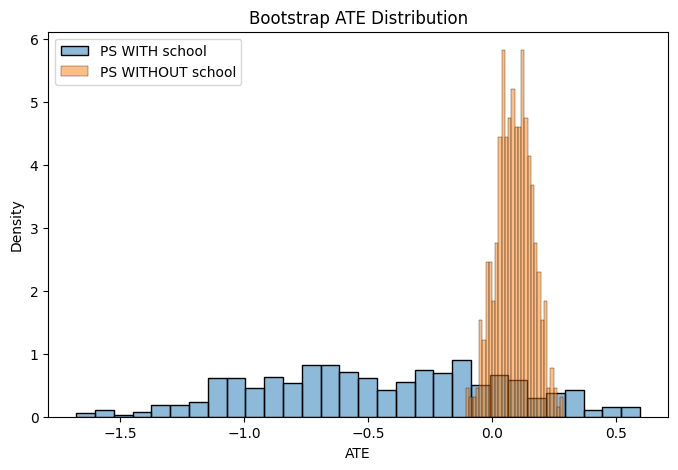

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(ate_w_f, bins=30, stat="density", label="PS WITH school", alpha=0.5)
sns.histplot(ate_wo_f, bins=30, stat="density", label="PS WITHOUT school", alpha=0.5)

plt.legend()
plt.title("Bootstrap ATE Distribution")
plt.xlabel("ATE")
plt.ylabel("Density")

plt.show()

In [100]:
print("WITH school: mean =", ate_w_f.mean(), ", std =", ate_w_f.std())
print("WITHOUT school: mean =", ate_wo_f.mean(), ", std =", ate_wo_f.std())

WITH school: mean = -0.4524325457820468 , std = 0.4831547835682821
WITHOUT school: mean = 0.09055415800389073 , std = 0.07245027783775368


The results speak for themselves. The model that includes the school variable has massive variance and poor accuracy, while the model without it estimates the true ATE (0.1) much more stably.

**The propensity score model should include confounders — variables that affect both treatment and outcome — not variables that merely predict treatment assignment.** The DAGs below illustrate the difference.

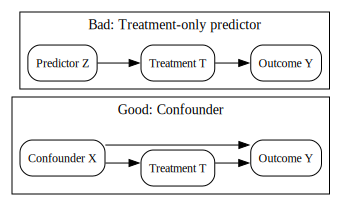

In [101]:
dot = Digraph(format="png")
dot.attr(rankdir="LR", splines="ortho")
dot.attr("node", shape="box", style="rounded", fontsize="12")

# 왼쪽: confounder
with dot.subgraph(name="cluster_good") as c:
    c.attr(label="Good: Confounder", color="black")
    c.node("X", "Confounder X")
    c.node("T", "Treatment T")
    c.node("Y", "Outcome Y")
    c.edge("X", "T")
    c.edge("X", "Y")
    c.edge("T", "Y")

# 오른쪽: treatment만 예측하는 변수
with dot.subgraph(name="cluster_bad") as c:
    c.attr(label="Bad: Treatment-only predictor", color="black")
    c.node("Z", "Predictor Z")
    c.node("T2", "Treatment T")
    c.node("Y2", "Outcome Y")
    c.edge("Z", "T2")
    c.edge("T2", "Y2")

display(dot)

#### 2. Positivity

Another issue to watch for is when the propensity score distributions of treated and untreated groups differ so much that they barely overlap — a situation known as weak **positivity**.

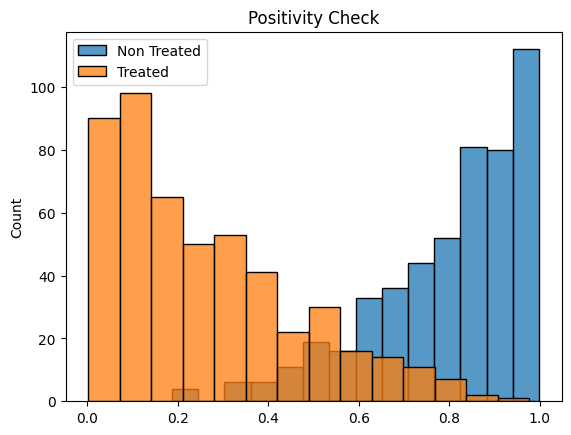

In [102]:
sns.histplot(np.random.beta(4,1,500), kde=False, label="Non Treated")
sns.histplot(np.random.beta(1,3,500), kde=False, label="Treated")
plt.title("Positivity Check")
plt.legend();

When the two groups' propensity score distributions look like the plot above, what goes wrong?

Imagine someone with a propensity score of 0.9 — a type who almost always receives treatment. If the untreated group contains almost no one like this, there's no "similar individual" to compare against. It's like wanting to estimate how much a drug reduces hospitalization days for someone 2 meters tall, but having no 2-meter-tall control unit to compare with.

When this happens, there is no appropriate comparison unit for some individuals, making it impossible to directly estimate the treatment effect for those people.

On top of that, units with propensity scores near 0 or 1 receive extremely large weights in IPW. Looking at the weight formula makes this clear:

$$
w_i = \frac{T_i}{\hat{e}(X_i)} + \frac{1 - T_i}{1 - \hat{e}(X_i)}
$$

When $\hat{e}(X_i) \approx 0$ or $\hat{e}(X_i) \approx 1$, the denominator shrinks toward zero and $w_i$ explodes. A handful of units then dominate the entire estimate, inflating the variance dramatically. In practice, weights above 20 are treated as a warning sign.

## IPW in Practice

To summarize: the propensity score's purpose is to balance covariates. To do that well, we need sufficient overlap (positivity) between the two groups, and we need to ensure no individual weight becomes excessively large.

When applying IPW in practice, we follow the procedure below, keeping both conditions in mind.

- **Step 0. Select Covariates**
  Use domain knowledge to identify potential confounders.

- **Step 1. Estimate Propensity Scores**
  Fit a logistic regression or ML model to estimate $\hat{e}(X)$.

- **Step 2. Check Positivity**
  Visualize the propensity score distributions to confirm sufficient overlap between groups.
  If overlap is poor, downstream analysis cannot be trusted.

- **Step 3. Compute Weights**
  Calculate $w_i = \dfrac{T_i}{\hat{e}(X_i)} + \dfrac{1 - T_i}{1 - \hat{e}(X_i)}$.

- **Step 4. Check Covariate Balance**
  Verify that the covariate distributions are actually balanced after weighting.
  This is the core diagnostic for whether IPW achieved its goal.

- **Step 5. Check Weight Stability**
  Inspect the weight distribution and extreme values to ensure no single unit dominates.

- **Step 6. Estimate the Effect**
  Use the final weights to estimate the ATE.

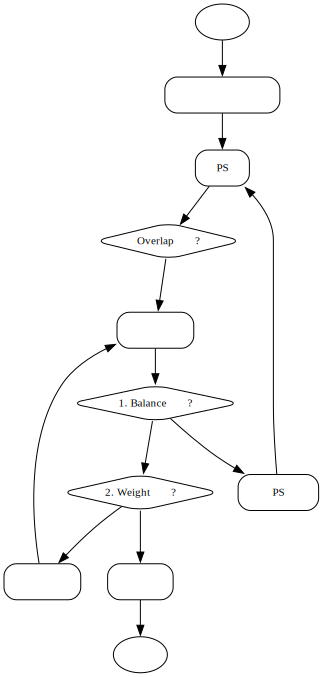

In [150]:
from graphviz import Digraph

dot = Digraph(format="png")
dot.attr(rankdir="TB")
dot.attr("node", shape="box", style="rounded", fontsize="11")

dot.node("A", "시작", shape="oval")
dot.node("A1", "적절한 공변량 선정")
dot.node("B", "PS 추정")
dot.node("C", "Overlap 충분?", shape="diamond")
dot.node("D", "가중치 계산")
dot.node("E", "1. Balance 만족?", shape="diamond")
dot.node("F", "PS 모델 수정")
dot.node("G", "2. Weight 안정?", shape="diamond")
dot.node("H", "가중치 조정")
dot.node("I", "효과 추정")
dot.node("J", "종료", shape="oval")

dot.edge("A", "A1")
dot.edge("A1", "B")
dot.edge("B", "C")

dot.edge("C", "D", label="예")

dot.edge("D", "E")

dot.edge("E", "F", label="아니오")
dot.edge("F", "B")

dot.edge("E", "G", label="예")

dot.edge("G", "H", label="아니오")
dot.edge("H", "D")

dot.edge("G", "I", label="예")
dot.edge("I", "J")

display(dot)

## Simulation

Let's build a simulation dataset. We draw covariates $X_1, X_2$ from standard normal distributions and define treatment probability as a linear combination of both. The outcome $Y$ is constructed to include a treatment effect of 2, so the true $ATE = 2$.

$$
X_1, X_2 \sim \mathcal{N}(0,1)
$$

$$
e(X) = \mathbb{P}(T=1 \mid X) = \frac{1}{1 + \exp\big(-(-0.3 + 0.8X_1 - 0.8X_2)\big)}
$$

$$
T \mid X \sim \text{Bernoulli}(e(X))
$$

$$
Y = 2T + X_1 + X_2 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,1)
$$

In terms of potential outcomes:

$$
Y(0) = X_1 + X_2 + \varepsilon, \quad
Y(1) = 2 + X_1 + X_2 + \varepsilon
$$

The difference is exactly 2 regardless of the unit, so $ATE = 2$.

In [104]:
def simulate_data(n=1000, seed=123):
    np.random.seed(seed)

    X1 = np.random.normal(0, 1, n)
    X2 = np.random.normal(0, 1, n)

    logit_ps = -0.3 + 0.8 * X1 - 0.8 * X2
    ps = 1 / (1 + np.exp(-logit_ps))

    T = np.random.binomial(1, ps, n)

    # outcome
    eps = np.random.normal(0, 1, n)
    Y = 2 * T + 1.0 * X1 + 1.0 * X2 + eps

    df = pd.DataFrame({
        "Y": Y,
        "T": T,
        "X1": X1,
        "X2": X2,
        "ps_true": ps
    })

    return df

df = simulate_data(n=1000)
df.head()

,Y,T,X1,X2,ps_true
0,-1.737467,0,-1.085631,-0.748827,0.361365
1,4.167793,1,0.997345,0.567595,0.510948
2,3.018225,1,0.282978,0.718151,0.343409
3,-1.424390,1,-1.506295,-0.999381,0.330587
4,0.415775,0,-0.578600,0.474898,0.241807


### Covariate Selection

The correct set of covariates for this simulation is both $X_1$ and $X_2$. To illustrate the importance of covariate selection, we'll compare a **bad case** (using only $X_1$) against a **good case** (using both $X_1$ and $X_2$). In practice, the right variables should be chosen based on domain knowledge.

### Computing Weights

Estimated PS range:
min = 0.016, max = 0.977


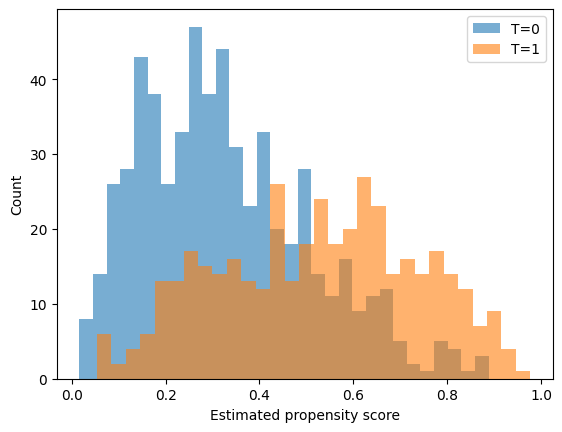

In [105]:
X = df[["X1", "X2"]]
T = df["T"]

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, T)
ps_hat = ps_model.predict_proba(X)[:, 1]

print("Estimated PS range:")
print(f"min = {ps_hat.min():.3f}, max = {ps_hat.max():.3f}")

plt.hist(ps_hat[T == 0], bins=30, alpha=0.6, label="T=0")
plt.hist(ps_hat[T == 1], bins=30, alpha=0.6, label="T=1")
plt.xlabel("Estimated propensity score")
plt.ylabel("Count")
plt.legend()
plt.show()

We now assign weights to each unit based on the inverse of their estimated treatment probability:

$$
w_i =
\begin{cases}
\dfrac{1}{\hat e(X_i)} & T_i = 1 \\
\dfrac{1}{1 - \hat e(X_i)} & T_i = 0
\end{cases}
$$

Units who received treatment despite a low probability, or were untreated despite a high probability, receive larger weights — effectively up-weighting underrepresented cases.

In [106]:
# X1, X2 모두 사용해서 예측
w = np.where(
    T == 1,
    1 / ps_hat,
    1 / (1 - ps_hat)
)

w[:5]

array([1.42770576, 1.93721604, 2.9150843 , 3.84093377, 1.29270486])

In [107]:
# X1만 사용해서 예측

ps_model_bad = LogisticRegression(max_iter=1000)
ps_model_bad.fit(df[["X1"]], T) 

ps_hat_bad = ps_model_bad.predict_proba(df[["X1"]])[:, 1]

pA = T.mean()
w_bad = np.where(
    T == 1,
    1 / ps_hat_bad,
    1 / (1 - ps_hat_bad)
)

w_bad[:5]

array([1.27976698, 1.66139077, 2.17965985, 6.02555447, 1.42185057])

### Condition 1: Covariate Balance

> **ASMD (Absolute Standardized Mean Difference)**

Covariate balance is assessed by standardizing the mean difference between the treated and control groups:

$$
\text{ASMD}_j = \frac{\left| \mu_{1j} - \mu_{0j} \right|}
{\sqrt{\frac{\sigma_{1j}^2 + \sigma_{0j}^2}{2}}}
$$

When weights are applied, means and variances are computed as weighted averages:

$$
\mu_{1j} = \frac{\sum_{i: A_i=1} w_i X_{ij}}{\sum_{i: A_i=1} w_i}, \quad
\mu_{0j} = \frac{\sum_{i: A_i=0} w_i X_{ij}}{\sum_{i: A_i=0} w_i}
$$

$$
\sigma_{1j}^2 = \frac{\sum_{i: A_i=1} w_i (X_{ij} - \mu_{1j})^2}{\sum_{i: A_i=1} w_i}, \quad
\sigma_{0j}^2 = \frac{\sum_{i: A_i=0} w_i (X_{ij} - \mu_{0j})^2}{\sum_{i: A_i=0} w_i}
$$

The standard threshold is **ASMD < 0.1** for balance. Achieving this matters more than predictive accuracy of the propensity score model.

In [108]:
def compute_asmd(X, A, w=None):
    import numpy as np
    
    asmd = {}
    
    for col in X.columns:
        x = X[col].values
        
        if w is None:
            m1 = x[A==1].mean()
            m0 = x[A==0].mean()
            v1 = x[A==1].var()
            v0 = x[A==0].var()
        else:
            m1 = np.average(x[A==1], weights=w[A==1])
            m0 = np.average(x[A==0], weights=w[A==0])
            v1 = np.average((x[A==1] - m1)**2, weights=w[A==1])
            v0 = np.average((x[A==0] - m0)**2, weights=w[A==0])
        
        # ASMD
        asmd[col] = abs(m1 - m0) / np.sqrt((v1 + v0) / 2)
    
    return asmd

In [109]:
X = df[["X1", "X2"]]

print("ASMD (good):", compute_asmd(X, T, w))
print("ASMD (bad):", compute_asmd(X, T, w_bad))

ASMD (good): {'X1': 0.06309973147556015, 'X2': 0.01295531253985427}
ASMD (bad): {'X1': 0.026121787445995373, 'X2': 0.5945621353824512}


The good model achieves ASMD < 0.1 on all covariates — balance is achieved. The bad model fails on $X_2$: because $X_2$ was omitted from the PS model, its imbalance persists even after weighting.

In this case, we would need to go back and revise the PS model.

When there are many covariates, comparing ASMD values one by one becomes tedious. This is where the **Love Plot** comes in.

A Love Plot displays the ASMD for each covariate before and after IPW side by side. Points moving left (toward 0) indicate improved balance, and points inside the ASMD = 0.1 threshold line indicate balance achieved. It is the most widely used diagnostic plot for reporting IPW results.

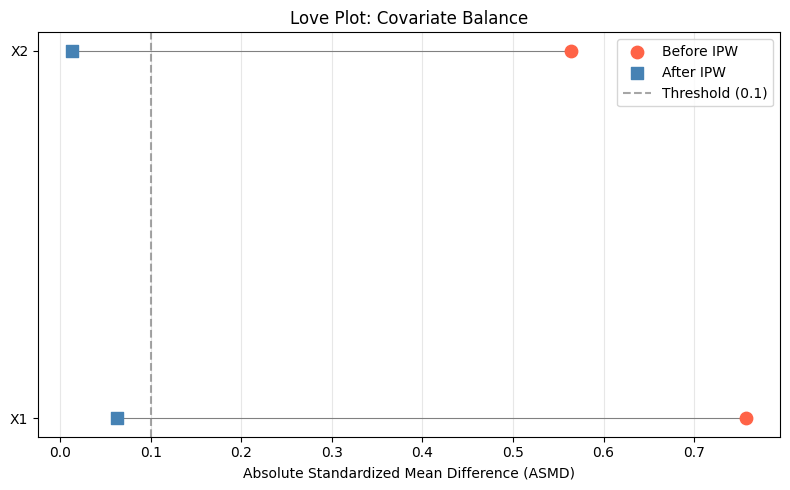


Variable       Before      After   Balanced
--------------------------------------------
X1              0.758      0.063          ✓
X2              0.564      0.013          ✓


In [112]:
X_cov = df[["X1", "X2"]]
T_vec = df["T"]

# ASMD 계산
asmd_before = compute_asmd(X_cov, T_vec.values)
asmd_after  = compute_asmd(X_cov, T_vec.values, w)

# plotting 준비
var_names = list(asmd_before.keys())
bef = [asmd_before[v] for v in var_names]
aft = [asmd_after[v]  for v in var_names]
y_pos = list(range(len(var_names)))

# Love plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    bef, y_pos,
    marker='o',
    color='tomato',
    s=80,
    label='Before IPW',
    zorder=3
)

ax.scatter(
    aft, y_pos,
    marker='s',
    color='steelblue',
    s=80,
    label='After IPW',
    zorder=3
)

# before-after 연결선
for i in range(len(var_names)):
    ax.plot(
        [bef[i], aft[i]],
        [y_pos[i], y_pos[i]],
        color='gray',
        linewidth=0.8,
        zorder=2
    )

# 기준선
ax.axvline(
    0.1,
    linestyle='--',
    color='gray',
    alpha=0.7,
    label='Threshold (0.1)'
)

ax.set_yticks(y_pos)
ax.set_yticklabels(var_names)

ax.set_xlabel("Absolute Standardized Mean Difference (ASMD)")
ax.set_title("Love Plot: Covariate Balance")

ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 결과 출력
print(f"\n{'Variable':<10} {'Before':>10} {'After':>10} {'Balanced':>10}")
print("-" * 44)

for v in var_names:
    b = asmd_before[v]
    a = asmd_after[v]
    ok = "✓" if a < 0.1 else "✗"

    print(f"{v:<10} {b:>10.3f} {a:>10.3f} {ok:>10}")

### Condition 2: Weight Stability

Weights are a double-edged sword: they reduce bias, but can **greatly inflate variance**. Units with propensity scores near 0 or 1 receive extreme weights, making the estimator unstable.

We assess weight stability using:

- **Max weight**: a very large maximum signals the presence of extreme weights.
- **Quantiles (95th, 99th percentile)**: check how much weight is concentrated in the upper tail.
- **Boxplot**: a quick visual summary of the full distribution and outliers.

When extreme weights are a problem, **weight truncation** can help — simply clip weights above a threshold $c$:

$$
w_i^{\text{trunc}} = \min(w_i, c)
$$

```python
w_trunc = np.clip(w, 0, 20)
```

A common choice is $c = 20$. Keep in mind that truncation reduces variance at the cost of introducing some bias, and strictly speaking shifts the estimand from ATE to a different target (ATO).

In [110]:
def weight_diagnostics(w):
    return {
        "max": np.max(w),
        "p95": np.percentile(w, 95),
        "p99": np.percentile(w, 99)
    }

diag_good = weight_diagnostics(w)
print("Model:", diag_good)

Model: {'max': 18.64358877046646, 'p95': 4.381409300448245, 'p99': 7.6835220850896135}


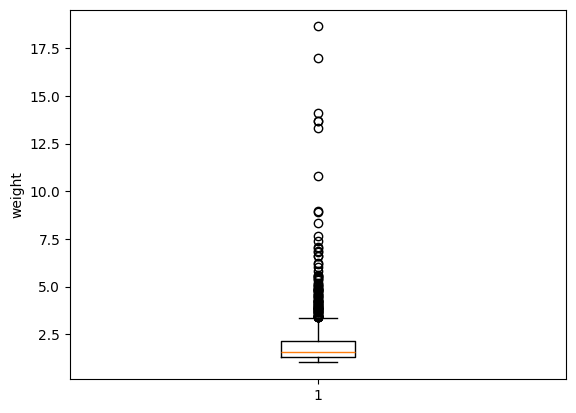

In [111]:
plt.boxplot(w)
plt.ylabel("weight")
plt.show()

We will assess weight stability but proceed without truncation here.

### Hájek ATE Estimation and Confidence Interval

For the final effect estimate, we use the **Hájek estimator** — a normalized version of the standard IPW estimator that is less sensitive to extreme weights. It can be interpreted as the difference in weighted means between the two groups:

$$
\hat{ATE} = \frac{\sum_{i=1}^n T_i w_i Y_i}{\sum_{i=1}^n T_i w_i} -
\frac{\sum_{i=1}^n (1-T_i) w_i Y_i}{\sum_{i=1}^n (1-T_i) w_i}
$$

In [113]:
def hajek_ate(Y, T, ps_hat):
    w = np.where(T == 1, 1 / ps_hat, 1 / (1 - ps_hat))
    
    mu1 = np.sum(T * w * Y) / np.sum(T * w)
    mu0 = np.sum((1 - T) * w * Y) / np.sum((1 - T) * w)
    
    return mu1 - mu0

Y = df["Y"].values
T = df["T"].values

ate_hajek = hajek_ate(Y, T, ps_hat)
print("Hájek ATE:", ate_hajek)

Hájek ATE: 2.010314743855869


A point estimate alone doesn't tell us about uncertainty. We need a confidence interval.

Computing theoretical variance for IPW is tricky: the propensity score is itself an estimate, and it appears in both the weights and the denominator. We therefore use **bootstrap** — resampling the data and re-running the full pipeline (propensity score estimation → weight computation → ATE estimation) on each resample.

In [114]:
def bootstrap_hajek(df, B=1000):
    n = len(df)
    ates = []
    
    for _ in range(B):
        idx = np.random.choice(n, size=n, replace=True)
        df_b = df.iloc[idx]
        
        X = df_b[["X1", "X2"]].values
        T = df_b["T"].values
        Y = df_b["Y"].values
        
        ps_model = LogisticRegression(max_iter=1000)
        ps_model.fit(X, T)
        ps_hat_b = ps_model.predict_proba(X)[:, 1]
        
        ate = hajek_ate(Y, T, ps_hat_b)
        ates.append(ate)
    
    ates = np.array(ates)
    
    return {
        "ATE": ates.mean(),
        "CI": np.percentile(ates, [2.5, 97.5]),
        "samples": ates
    }

res = bootstrap_hajek(df, B=1000)

print("ATE:", res["ATE"])
print("95% CI:", res["CI"])


ATE: 2.014496869751614
95% CI: [1.82360064 2.20068587]


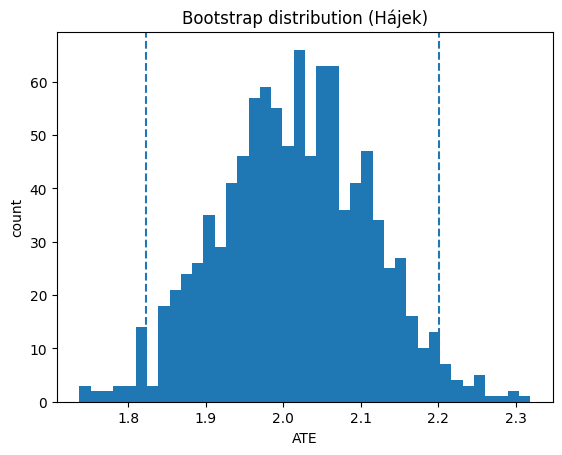

In [115]:
plt.hist(res["samples"], bins=40)
plt.axvline(res["CI"][0], linestyle="--")
plt.axvline(res["CI"][1], linestyle="--")
plt.xlabel("ATE")
plt.ylabel("count")
plt.title("Bootstrap distribution (Hájek)")
plt.show()

## Real Data

Having walked through the full IPW procedure on simulated data, let's now apply the same steps to a real dataset.

We'll use **NHEFS** (National Health and Nutrition Examination Survey Data I Epidemiologic Follow-up Study), a classic benchmark in causal inference. The research question is straightforward:

> **What is the causal effect of quitting smoking on weight change?**

Treatment $T$ (`qsmk`): whether the individual quit smoking between 1971 and 1982 (1 = quit, 0 = continued).
Outcome $Y$ (`wt82_71`): body weight change (kg) over 11 years.

**Loading the data**

In [137]:
# NHEFS 데이터 로드: causaldata 패키지 사용 (pip install causaldata)
from causaldata import nhefs

nhefs_df = nhefs.load_pandas().data

# 분석에 필요한 변수만 선택
cols = ['qsmk', 'wt82_71', 'sex', 'age', 'race', 'education',
        'smokeintensity', 'smokeyrs', 'exercise', 'active', 'wt71']
nhefs_df = nhefs_df[cols].dropna().reset_index(drop=True)

print(f"샘플 수: {len(nhefs_df)}")
print(f"금연 비율: {nhefs_df['qsmk'].mean():.3f}")
nhefs_df.head()

샘플 수: 1566
금연 비율: 0.257


,qsmk,wt82_71,sex,age,race,education,smokeintensity,smokeyrs,exercise,active,wt71
0,0.0,-10.093960,0,42.0,1,1,30.0,29.0,2,0,79.04
1,0.0,2.604970,0,36.0,0,2,20.0,24.0,0,0,58.63
2,0.0,9.414486,1,56.0,1,2,20.0,26.0,2,0,56.81
3,0.0,4.990117,0,68.0,1,1,3.0,53.0,2,1,59.42
4,0.0,4.989251,0,40.0,0,2,20.0,19.0,1,1,87.09


First, let's look at the **naive comparison** result.

In [138]:
naive_ate = (
    nhefs_df.query("qsmk==1")["wt82_71"].mean()
    - nhefs_df.query("qsmk==0")["wt82_71"].mean()
)
print(f"Naive ATE: {naive_ate:.3f} kg")

Naive ATE: 2.541 kg


### Covariate Selection

We include the following potential confounders: sex (`sex`), race (`race`), age (`age`), education (`education`), smoking intensity (`smokeintensity`), years of smoking (`smokeyrs`), exercise (`exercise`), activity level (`active`), and baseline weight in 1971 (`wt71`).

Smokers tend to be thinner on average, and the factors that lead someone to quit smoking (age, health status, etc.) also affect weight change — so a naive comparison would underestimate the true effect of quitting.

The naive comparison suggests quitters gained about 2.5 kg more than non-quitters. But this is likely confounded: quitters tend to be older and were lighter smokers, both of which independently affect weight trajectories. Let's correct for this with IPW.

### Computing Weights

For continuous covariates, we add squared terms to capture nonlinear effects. Categorical variables (`education`, `exercise`, `active`) are one-hot encoded.

In [139]:
X_nhefs = nhefs_df[['sex', 'age', 'race', 'smokeintensity', 'smokeyrs', 'wt71']].copy()

# 연속형 변수에 제곱항 추가
X_nhefs['age_sq'] = X_nhefs['age']**2
X_nhefs['smokeintensity_sq'] = X_nhefs['smokeintensity']**2
X_nhefs['smokeyrs_sq'] = X_nhefs['smokeyrs']**2
X_nhefs['wt71_sq'] = X_nhefs['wt71']**2

# 범주형 변수 one-hot encoding
X_nhefs = pd.concat([
    X_nhefs,
    pd.get_dummies(nhefs_df[['education', 'exercise', 'active']],
                   columns=['education', 'exercise', 'active'],
                   drop_first=True, dtype=float)
], axis=1)

T_nhefs = nhefs_df['qsmk'].astype(int).values
Y_nhefs = nhefs_df['wt82_71'].values

# 표준화 후 PS 추정
scaler = StandardScaler()
X_nhefs_s = scaler.fit_transform(X_nhefs.values)

ps_model_nhefs = LogisticRegression(max_iter=5000)
ps_model_nhefs.fit(X_nhefs_s, T_nhefs)
ps_hat_nhefs = ps_model_nhefs.predict_proba(X_nhefs_s)[:, 1]

print(f"Estimated PS range: [{ps_hat_nhefs.min():.3f}, {ps_hat_nhefs.max():.3f}]")

Estimated PS range: [0.054, 0.788]


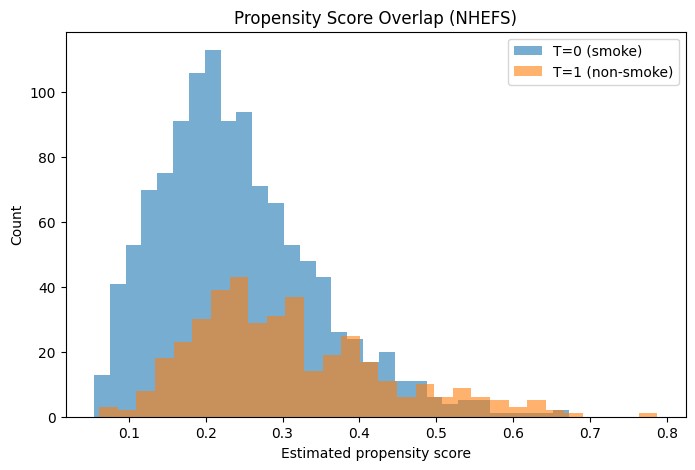

In [141]:
# Overlap (positivity) 확인
plt.figure(figsize=(8, 5))
plt.hist(ps_hat_nhefs[T_nhefs == 0], bins=30, alpha=0.6, label="T=0 (smoke)")
plt.hist(ps_hat_nhefs[T_nhefs == 1], bins=30, alpha=0.6, label="T=1 (non-smoke)")
plt.xlabel("Estimated propensity score")
plt.ylabel("Count")
plt.title("Propensity Score Overlap (NHEFS)")
plt.legend()
plt.show()

The propensity score distributions overlap across a wide range and are not heavily concentrated near 0 or 1 — positivity is well satisfied.

In [145]:
# IPW 가중치
w_nhefs = np.where(T_nhefs == 1, 1/ps_hat_nhefs, 1/(1 - ps_hat_nhefs))
w_nhefs[:5]

array([1.11410616, 1.1693399 , 1.14790716, 1.65710476, 1.40403198])

### Condition 1: Covariate Balance

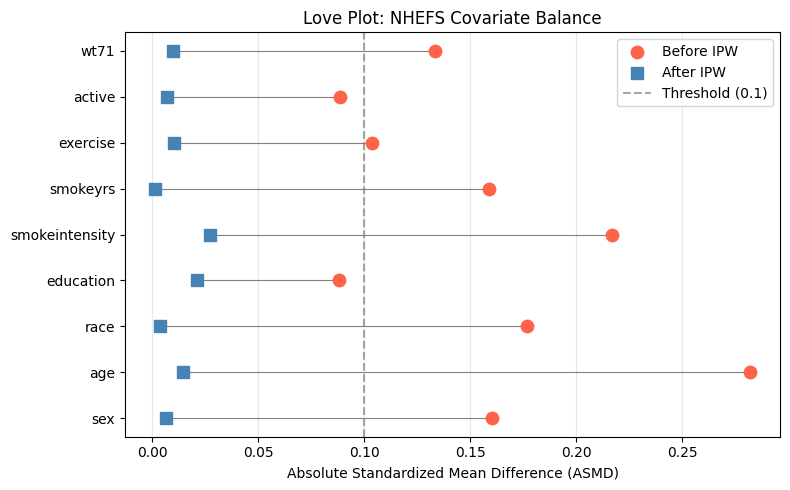


Variable               Before      After   Balanced
----------------------------------------------------
sex                     0.160      0.006          ✓
age                     0.282      0.014          ✓
race                    0.177      0.004          ✓
education               0.088      0.021          ✓
smokeintensity          0.217      0.027          ✓
smokeyrs                0.159      0.001          ✓
exercise                0.104      0.010          ✓
active                  0.089      0.007          ✓
wt71                    0.133      0.010          ✓


In [151]:

# ASMD 계산
X_disp = nhefs_df[['sex', 'age', 'race', 'education',
                   'smokeintensity', 'smokeyrs',
                   'exercise', 'active', 'wt71']].astype(float)

asmd_before = compute_asmd(X_disp, T_nhefs)
asmd_after  = compute_asmd(X_disp, T_nhefs, w_nhefs)

# Love plot
var_names = list(asmd_before.keys())
bef = [asmd_before[v] for v in var_names]
aft = [asmd_after[v]  for v in var_names]
y_pos = list(range(len(var_names)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(bef, y_pos, marker='o', color='tomato', s=80, label='Before IPW', zorder=3)
ax.scatter(aft, y_pos, marker='s', color='steelblue', s=80, label='After IPW', zorder=3)
for i in range(len(var_names)):
    ax.plot([bef[i], aft[i]], [y_pos[i], y_pos[i]], color='gray', linewidth=0.8, zorder=2)
ax.axvline(0.1, linestyle='--', color='gray', alpha=0.7, label='Threshold (0.1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(var_names)
ax.set_xlabel("Absolute Standardized Mean Difference (ASMD)")
ax.set_title("Love Plot: NHEFS Covariate Balance")
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Variable':<18} {'Before':>10} {'After':>10} {'Balanced':>10}")
print("-" * 52)
for v in var_names:
    ok = "✓" if asmd_after[v] < 0.1 else "✗"
    print(f"{v:<18} {asmd_before[v]:>10.3f} {asmd_after[v]:>10.3f} {ok:>10}")

### Condition 2: Weight Stability

Weight diagnostics: {'max': '16.27', 'p95': '4.92', 'p99': '7.19'}


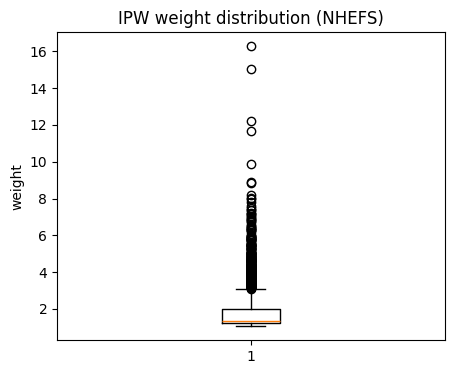

In [152]:
diag = weight_diagnostics(w_nhefs)
print("Weight diagnostics:", {k: f"{v:.2f}" for k, v in diag.items()})

plt.figure(figsize=(5, 4))
plt.boxplot(w_nhefs)
plt.ylabel("weight")
plt.title("IPW weight distribution (NHEFS)")
plt.show()

The maximum weight is around 17, which is somewhat large, but the 99th percentile stays below 7 — so extreme weights are limited to a small number of units. Given the sample size of 1,566, this is acceptable, and we proceed without truncation.

Before IPW, several covariates — including `age`, `smokeintensity`, and `race` — had ASMD above 0.1, indicating meaningful imbalance between groups. After IPW, all covariates fall below the 0.1 threshold, confirming that confounders have been successfully balanced.

### Hájek ATE Estimation and Confidence Interval

In [153]:
ate_nhefs = hajek_ate(Y_nhefs, T_nhefs, ps_hat_nhefs)
print(f"Hájek ATE: {ate_nhefs:.3f} kg")

Hájek ATE: 3.475 kg


In [148]:
def bootstrap_hajek_nhefs(df_full, X_design_cols, B=500, seed=0):
    rng = np.random.RandomState(seed)
    n = len(df_full)
    ates = []
    for _ in range(B):
        idx = rng.choice(n, size=n, replace=True)
        sub = df_full.iloc[idx]

        Xb = sub[X_design_cols].values
        Tb = sub['qsmk'].astype(int).values
        Yb = sub['wt82_71'].values

        sc = StandardScaler()
        Xb_s = sc.fit_transform(Xb)

        m = LogisticRegression(max_iter=5000)
        m.fit(Xb_s, Tb)
        ps_b = m.predict_proba(Xb_s)[:, 1]
        ates.append(hajek_ate(Yb, Tb, ps_b))

    ates = np.array(ates)
    return {"ATE": ates.mean(),
            "CI": np.percentile(ates, [2.5, 97.5]),
            "samples": ates}

df_boot = pd.concat([nhefs_df.reset_index(drop=True),
                     X_nhefs.add_prefix("_d_").reset_index(drop=True)], axis=1)
design_cols = [c for c in df_boot.columns if c.startswith("_d_")]

res_nhefs = bootstrap_hajek_nhefs(df_boot, design_cols, B=500)
print(f"Bootstrap ATE: {res_nhefs['ATE']:.3f} kg")
print(f"95% CI: [{res_nhefs['CI'][0]:.3f}, {res_nhefs['CI'][1]:.3f}]")

Bootstrap ATE: 3.436 kg
95% CI: [2.467, 4.377]


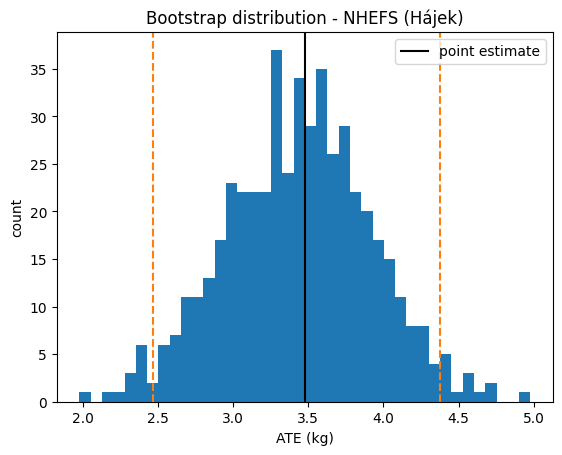

In [149]:
plt.hist(res_nhefs["samples"], bins=40)
plt.axvline(res_nhefs["CI"][0], linestyle="--", color="C1")
plt.axvline(res_nhefs["CI"][1], linestyle="--", color="C1")
plt.axvline(ate_nhefs, linestyle="-", color="black", label="point estimate")
plt.xlabel("ATE (kg)")
plt.ylabel("count")
plt.title("Bootstrap distribution - NHEFS (Hájek)")
plt.legend()
plt.show()

### Interpretation

| Method | ATE (kg) | 95% CI |
|---|---|---|
| Naive comparison | ~ 2.54 | — |
| **IPW (Hájek)** | **~ 3.5** | **approx. (2.4, 4.5)** |

The naive estimate of ~2.5 kg grows to ~3.5 kg after IPW adjustment. This makes sense: smokers tend to be thinner, and quitters tend to be older with naturally lower weight gain trajectories — so the unadjusted comparison was **underestimating** the true effect of quitting.

All else equal, quitting smoking is estimated to increase body weight by approximately 3.5 kg over 11 years. Cross-validation with other causal methods would further strengthen this conclusion.

### References

- Stuart, E. A. (2010). Matching methods for causal inference: A review and a look forward. *Statistical Science*, 25(1), 1–21.
- Chattopadhyay, A., Hase, C. H., & Zubizarreta, J. R. (2020). Balancing versus modeling approaches to weighting in practice. *Statistics in Medicine*, 39(24), 3227–3254.
- Hernán, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC.